<a href="https://colab.research.google.com/github/ashorinajufan/KUMPULAN-TUGAS-DATA-MINING-/blob/main/DATA_PREPROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#pemanggilan data
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
#melihat statistika deskriptif
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# DETEKSI MISSING VALUE

In [7]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
np.sum(df.isnull())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
#mengetahui jumlah missing value di seluruh dataset
df.isnull().sum().sum()

np.int64(866)

# HANDLING MISSING VALUE

1. Age

Pada variabel Age digunakan nilai rata-rata (mean) karena bersifat numerik dan dapat mewakili distribusi data.

In [10]:
#melihat isi dalam kolom Age
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [11]:
#jumlah missing value
np.sum(df['Age'].isnull())

np.int64(177)

In [12]:
#mengisi missing value
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [13]:
#jumlah missing value
np.sum(df['Age'].isnull())

np.int64(0)

2. Cabin

Pada variabel Cabin digunakan label “Unknown” karena memiliki banyak kategori unik, sehingga tidak tepat menggunakan mean atau mode.

In [14]:
#melihat isi dalam kolom Cabin
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [15]:
#jumlah missing value
np.sum(df['Cabin'].isnull())

np.int64(687)

In [16]:
#mengisi missing value
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [17]:
#jumlah missing value
np.sum(df['Cabin'].isnull())

np.int64(0)

3. Embarked

Pada variabel Embarked digunakan nilai modus (mode) karena merupakan data kategorikal sehingga nilai yang paling sering muncul dianggap paling representatif.

In [18]:
#melihat isi dalam kolom Embarked
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [19]:
#jumlah missing value
np.sum(df['Embarked'].isnull())

np.int64(2)

In [20]:
#mengisi missing value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [21]:
#jumlah missing value
np.sum(df['Embarked'].isnull())

np.int64(0)

In [22]:
np.sum(df.isnull())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# CEK DAN PENANGANAN OUTLIER

Outlier hanya dianalisis pada data numerik karena konsep outlier berkaitan dengan nilai ekstrem dalam distribusi data. Oleh karena itu, kolom yang digunakan adalah Age, Fare, SibSp, dan Parch. Kolom lain seperti Sex dan Embarked bersifat kategorikal sehingga tidak dianalisis menggunakan metode outlier.

1. Boxplot

Untuk memperjelas keberadaan outlier, digunakan visualisasi boxplot. Boxplot menampilkan distribusi data berdasarkan kuartil serta menunjukkan nilai ekstrem yang berada di luar batas.

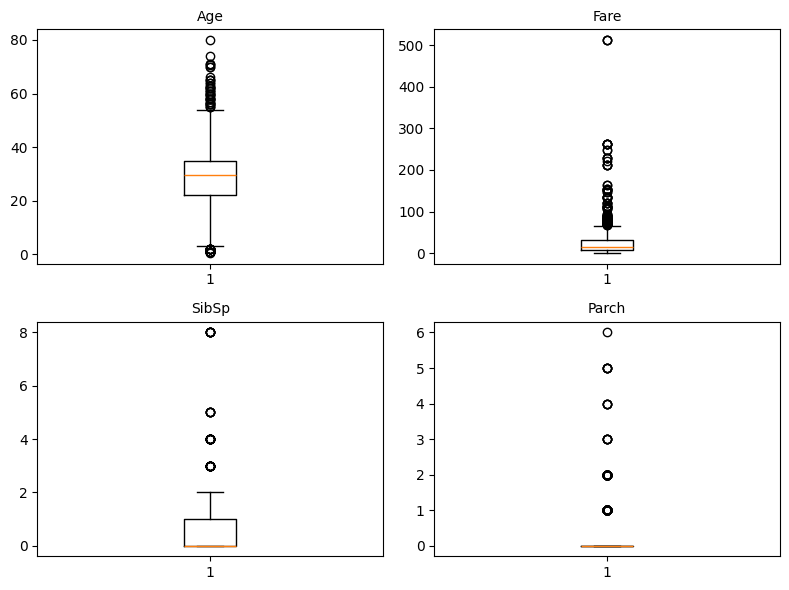

In [24]:
import matplotlib.pyplot as plt

kolom_numerik = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(8, 6))  # ukuran lebih kecil & proporsional
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    axes[i].boxplot(df[kolom])
    axes[i].set_title(kolom, fontsize=10)

plt.tight_layout()
plt.show()

2. IQR

Metode Interquartile Range (IQR) menggunakan kuartil untuk menentukan batas bawah dan batas atas data. Data yang berada di luar batas tersebut dianggap sebagai outlier.

In [25]:
for kolom in kolom_numerik:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[kolom] < lower) | (df[kolom] > upper)]
    print(f"{kolom} jumlah outlier:", len(outlier))

Age jumlah outlier: 66
Fare jumlah outlier: 116
SibSp jumlah outlier: 46
Parch jumlah outlier: 213


3. Winsorizing

Metode capping (winsorizing), nilai yang berada di bawah batas bawah akan diganti dengan nilai batas bawah, dan nilai yang berada di atas batas atas akan diganti dengan nilai batas atas.

In [26]:
for kolom in kolom_numerik:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[kolom] = np.where(df[kolom] < lower, lower, df[kolom])
    df[kolom] = np.where(df[kolom] > upper, upper, df[kolom])

Setelah dilakukan penanganan, data divisualisasikan kembali menggunakan boxplot.

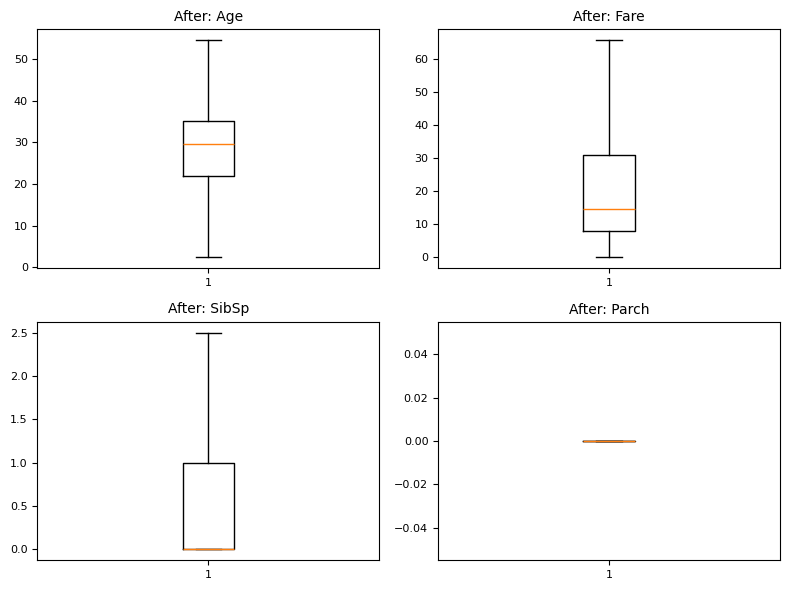

In [27]:
#cek boxplot lagi
import matplotlib.pyplot as plt

kolom_numerik = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(8, 6))  # ukuran kecil & rapi
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    axes[i].boxplot(df[kolom])
    axes[i].set_title(f'After: {kolom}', fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

# ENCODING DATA KATEGORIK

Encoding merupakan proses mengubah data kategorikal (teks) menjadi data numerik (angka) agar dapat diproses dalam analisis data mining atau machine learning. Hal ini diperlukan karena sebagian besar algoritma hanya dapat mengolah data dalam bentuk numerik.

In [28]:
#cek kolom kategorik
df.select_dtypes(include=['object']).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [29]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [30]:
df = pd.get_dummies(df, columns=['Embarked'])

In [31]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['Cabin'] = df['Cabin'].str[0]
df = pd.get_dummies(df, columns=['Cabin'])

In [32]:
df['Name_length'] = df['Name'].apply(len)
df['Ticket_length'] = df['Ticket'].apply(len)

In [33]:
#cek data terakhir
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    int64  
 5   Age            891 non-null    float64
 6   SibSp          891 non-null    float64
 7   Parch          891 non-null    float64
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Embarked_C     891 non-null    bool   
 11  Embarked_Q     891 non-null    bool   
 12  Embarked_S     891 non-null    bool   
 13  Cabin_A        891 non-null    bool   
 14  Cabin_B        891 non-null    bool   
 15  Cabin_C        891 non-null    bool   
 16  Cabin_D        891 non-null    bool   
 17  Cabin_E        891 non-null    bool   
 18  Cabin_F   